# Treinamento

As colunas da database são: PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked

### Pré processamneto realizado
    As colunas 'PassengerId',"Name",'Ticket',"Cabin" foram cortadas por serem consideradas ruído ou pouco significativas para o resultado.
    A coluna 'Sex' foi transformada em valor binário
    A coluna 'Embarked' foi transformada em 3 colunas binárias cada uma referente a um dos valores possiveis de onde a pessoa embarcou.

### Modelo usado
    O xgboost foi usado como modelo caixa preta que cria uma série de arvores de decisão (Tradicionalmente considerados caixa branca) e usa o resultado dessas arvores para tomar uma decisão, de modo que a sáida é matematicamente complexa o suficiente para ser humamente dificil explicar.

### Hiperparametros
    A taxa de aprendizado é de 0.1 e a profundidade da árvore é de 5. Outras combinações de valores foram tentadas mas essa atingiu o maior resultado em termos de acurácia (0.8182).
    _Obs_: Usando os parametros padrão do xgboost a acurácia foi de 0.7622

### Valores alterados
    Houveram tentativas de ajuste menores, como cortar outras colunas, mas todas as combinações e variações diferentes das que estão na célula abaixo apresentaram redução na acurácia.
    

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

dataset = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(dataset)

df = df.drop(['PassengerId',"Name",'Ticket',"Cabin"],axis=1).dropna()

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df = pd.get_dummies(df, columns=['Embarked'])

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(learning_rate=0.1,max_depth=5)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.8182


### SLM
O bloco abaixo é responsável por conectar com o SLM qwen2.5 rodando localmente.
Antes de executar esse bloco é importante ter o SLM rodando na sua maquina:

#### Via docker
> docker model run ai/qwen2.5

#### Via Ollama
Caso você tenha rodado o projeto com:
> docker compose -f docker-compose.yml -f docker-compose-ollama.yml up -d

Você pode rodar o modelo pelo ollama com o comando:
> docker compose exec qwen_slm ollama run qwen2.5

In [2]:
import os
import requests

_QWEN_WORKING_URL = None

def get_qwen_url():
    global _QWEN_WORKING_URL
    
    if _QWEN_WORKING_URL:
        return _QWEN_WORKING_URL
        
    print("Buscando a URL do Qwen...")
    url_env = os.getenv("QWEN_URL")
    urls_para_testar = [url_env] if url_env else []
    
    urls_para_testar.extend([
        "http://qwen_slm:11434/api/generate",
        "http://qwen:11434/api/generate",
        "http://host.docker.internal:11434/api/generate",
        "http://localhost:11434/api/generate",
        "http://127.0.0.1:11434/api/generate"
    ])
    
    teste_payload = {"model": "qwen2.5", "prompt": "teste", "stream": False}
    
    for url in urls_para_testar:
        try:
            resposta = requests.post(url, json=teste_payload, timeout=30)
            if resposta.status_code == 200:
                _QWEN_WORKING_URL = url
                return _QWEN_WORKING_URL
        except requests.exceptions.RequestException:
            continue
            
    raise ConnectionError("Erro Crítico: Não encontrei o modelo Qwen em nenhuma das rotas.")

def ask_qwen(prompt):
    url = get_qwen_url()
    
    payload = {
        "model": "qwen2.5", 
        "prompt": prompt,
        "stream": False
    }
    
    try:
        resposta = requests.post(url, json=payload, timeout=30)
        if resposta.status_code == 200:
            return resposta.json().get("response", "").strip()
        else:
            return f"Erro na API: Status {resposta.status_code}"
    except requests.exceptions.RequestException as e:
        return f"Erro de conexão: {e}"

In [3]:
import numpy as np

PROMPT_BASE = """Você é um especialista em análise de dados avaliando a sobrevivência de passageiros do Titanic.

DICIONÁRIO DE DADOS:
- Pclass: 1 = 1ª Classe, 2 = 2ª Classe, 3 = 3ª Classe.
- Sex: 0 = Mulher, 1 = Homem.
- Age: Idade em anos.
- SibSp: Número de irmãos/cônjuges a bordo.
- Parch: Número de pais/filhos a bordo.
- Fare: Tarifa paga.
- Embarked_C, Embarked_Q, Embarked_S: Valor 1.0 indica o porto de embarque.

DIRETRIZES DE EXPLICABILIDADE (SHAP):
- Valores SHAP > 0: Contribuem para a predição de sobrevivência.
- Valores SHAP < 0: Contribuem para a predição de não sobrevivência (óbito).
- A magnitude absoluta indica a força da influência da variável.

DADOS DA INSTÂNCIA E VALORES SHAP:
{detalhes}

INSTRUÇÃO:
Com base estritamente no dicionário de dados e nos valores SHAP fornecidos, escreva um parágrafo conciso explicando os principais fatores que determinaram a predição para este passageiro. Inicie o texto informando a predição final (sobreviveu ou morreu). Utilize linguagem natural, omitindo os valores numéricos e os nomes técnicos das variáveis."""

PROMPT_SINTESE = """Você é um especialista em análise de dados. Abaixo estão 5 explicações locais geradas por um método de explicabilidade sob restrição computacional.

{textos_combinados}

INSTRUÇÃO:
Analise as 5 explicações. Identifique os determinantes de consenso e descarte as flutuações e contradições. Escreva um parágrafo único, fluido e definitivo, sintetizando a motivação real para a predição deste passageiro."""

def extrair_valores_shap(shap_output):
    valores_brutos = np.array(shap_output)
    if valores_brutos.ndim == 3:
        return valores_brutos[0, :, 1]
    elif isinstance(shap_output, list):
        return shap_output[1][0]
    return valores_brutos[0]

def formatar_detalhes(valores_shap, valores_reais, colunas):
    exp = [(colunas[i], float(valores_shap[i])) for i in range(len(colunas))]
    exp_ordenada = sorted(exp, key=lambda x: abs(x[1]), reverse=True)
    return "\n".join([f"- {feat} (Valor real: {valores_reais.get(feat)}): Peso SHAP = {val:.4f}" for feat, val in exp_ordenada])

### Seleciona um passageiro e pega os valores de Shap dele.
São criadas 5 grupos de valores diferentes, cada um deles gerado usando um numero de exemplos diferentes. (Pode ser variado modificando valores na lista nsamples_lista alterando n na chamada na função explainer.shap_values, ex: nsamples=n*5). 

In [4]:
import shap

indice_passageiro = 0
instancia = X_test.iloc[indice_passageiro:indice_passageiro+1]
valores_reais = instancia.to_dict(orient='records')[0]
colunas_train = X_train.columns

print(f"--- Dados do Passageiro (Índice {indice_passageiro}) ---")
for coluna, valor in valores_reais.items():
    print(f"  {coluna}: {valor}")
print("-" * 50 + "\n")

background = shap.sample(X_train, 10)

def predict_fn(X):
    return model.predict_proba(X)

explainer = shap.KernelExplainer(predict_fn, background)

nsamples_lista = [10, 15, 20, 25, 30]
explicacoes_pobres = []
textos_pobres = []

for n in nsamples_lista:
    shap_values_ruido = explainer.shap_values(instancia, nsamples=n*5, silent=True)
    valores_shap = extrair_valores_shap(shap_values_ruido)
    
    exp_formatada = [(colunas_train[i], float(valores_shap[i])) for i in range(len(colunas_train))]
    explicacoes_pobres.append(exp_formatada)
    
    texto_detalhes = formatar_detalhes(valores_shap, valores_reais, colunas_train)
    prompt_slm = PROMPT_BASE.format(detalhes=texto_detalhes)
    
    resposta_qwen = ask_qwen(prompt_slm)
    textos_pobres.append(resposta_qwen)

for idx, exp in enumerate(explicacoes_pobres):
    print(f"--- Explicação {idx+1} (nsamples={nsamples_lista[idx]*5}) ---")
    exp_ordenada = sorted(exp, key=lambda x: abs(x[1]), reverse=True)
    for feature, valor in exp_ordenada:
        print(f"  {feature}: {valor:.4f}")
    print()

for idx, texto in enumerate(textos_pobres):
    print(f"--- Explicação Textual {idx+1} ---")
    print(texto)
    print()

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Dados do Passageiro (Índice 0) ---
  Pclass: 1
  Sex: 0
  Age: 24.0
  SibSp: 0
  Parch: 0
  Fare: 69.3
  Embarked_C: True
  Embarked_Q: False
  Embarked_S: False
--------------------------------------------------

Buscando a URL do Qwen...
--- Explicação 1 (nsamples=50) ---
  Sex: 0.3403
  Pclass: 0.0685
  Age: -0.0505
  Fare: 0.0435
  Parch: -0.0182
  Embarked_S: 0.0115
  Embarked_C: 0.0061
  SibSp: 0.0012
  Embarked_Q: 0.0000

--- Explicação 2 (nsamples=75) ---
  Sex: 0.3469
  Pclass: 0.0849
  Age: -0.0367
  Fare: 0.0150
  Parch: -0.0102
  Embarked_C: 0.0080
  SibSp: -0.0070
  Embarked_S: 0.0015
  Embarked_Q: 0.0000

--- Explicação 3 (nsamples=100) ---
  Sex: 0.3413
  Pclass: 0.0739
  Age: -0.0411
  Fare: 0.0249
  Embarked_C: 0.0094
  Parch: -0.0092
  Embarked_S: 0.0085
  SibSp: -0.0052
  Embarked_Q: 0.0000

--- Explicação 4 (nsamples=125) ---
  Sex: 0.3397
  Pclass: 0.0772
  Age: -0.0387
  Fare: 0.0212
  Parch: -0.0112
  Embarked_S: 0.0089
  Embarked_C: 0.0061
  SibSp: -0.0007
 

In [5]:
import os
from dotenv import load_dotenv
from google import genai

load_dotenv()
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

textos_combinados = "\n\n".join([f"Explicação {i+1}:\n{texto}" for i, texto in enumerate(textos_pobres)])
prompt_sintese_final = PROMPT_SINTESE.format(textos_combinados=textos_combinados)

print("Iniciando a síntese com o Qwen local...\n")
explicacao_forte_qwen = ask_qwen(prompt_sintese_final)
print("=== SÍNTESE (QWEN SLM) ===")
print(explicacao_forte_qwen)
print("\n" + "="*50 + "\n")

print("Iniciando a síntese com a API do Gemini...\n")
resposta_gemini = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt_sintese_final
)
print("=== SÍNTESE (GEMINI LLM) ===")
print(resposta_gemini.text)

Iniciando a síntese com o Qwen local...

=== SÍNTESE (QWEN SLM) ===
O passageiro predito sobreviveu, com a predição sendo principalmente influenciada pelo fato de ser mulher, a classe de primeira classe em que viajava, e a baixa idade. Embora o gênero tenha sido o determinante mais significativo em todas as explicações, destacando a alta probabilidade de sobrevivência para mulheres, a classe social e a idade também contribuíram positivamente, mas com efeitos variáveis. A tarifa mais alta, embora tenha um efeito positivo, foi considerada menos influente comparativamente. O embarque no porto C teve um leve impacto positivo em algumas explicações, mas não foi um fator decisivo. Contrariamente, ser homem, não ser membro da primeira classe, e a idade de 24 anos (apesar de ser jovem) contribuíram para a predição de sobrevivência com efeitos menores. As explicações que indicaram não sobrevivência, embora tenham destacado a influência do gênero, classe e idade, também confirmaram a predominânc

## NOVAS METRICAS PARA VALIDAÇÃO

No bloco abaixo verificamos oque seria uma resposta "boa", onde um LLM (no nosso caso, o gemini) usa os valores de shap criados com 2000 samples. 

--- Métrica de Variância (Desvio Padrão sob Restrição) ---
  Fare: 0.0095
  Pclass: 0.0053
  Age: 0.0048
  Parch: 0.0034
  Embarked_S: 0.0033
  SibSp: 0.0030
  Sex: 0.0029
  Embarked_C: 0.0017
  Embarked_Q: 0.0000


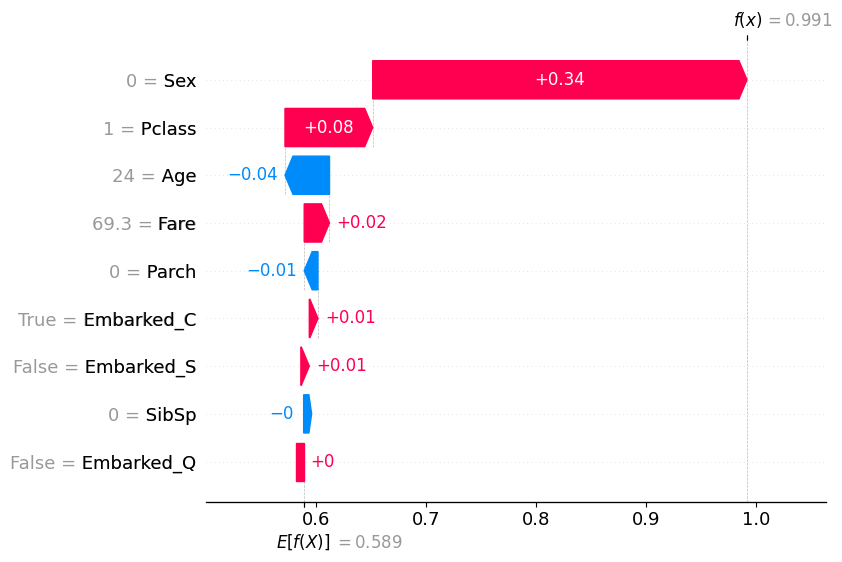


Iniciando a explicação do Baseline com a API do Gemini...

=== EXPLICAÇÃO DO BASELINE (SHAP 2000 + GEMINI) ===
Este passageiro foi previsto como sobrevivente. A principal razão para essa predição foi o fato de ser mulher. Além disso, a sua classe de viagem e a tarifa paga contribuíram significativamente para as suas chances de sobrevivência. Por outro lado, a idade do passageiro diminuiu ligeiramente essa probabilidade, e a ausência de pais, filhos, irmãos ou cônjuges a bordo também teve um impacto negativo, embora menor.


In [6]:
import matplotlib.pyplot as plt

valores_por_feature = {feat: [] for feat in colunas_train}
for exp in explicacoes_pobres:
    for feat, val in exp:
        valores_por_feature[feat].append(val)

print("--- Métrica de Variância (Desvio Padrão sob Restrição) ---")
desvios = []
for feat, valores in valores_por_feature.items():
    desvio = np.std(valores)
    desvios.append((feat, desvio))

desvios_ordenados = sorted(desvios, key=lambda x: x[1], reverse=True)
for feat, desvio in desvios_ordenados:
    print(f"  {feat}: {desvio:.4f}")

shap_values_completo = explainer.shap_values(instancia, nsamples=2000, silent=True)
valores_completos = extrair_valores_shap(shap_values_completo)

base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1 else explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

explicacao_obj = shap.Explanation(
    values=valores_completos,
    base_values=base_val,
    data=instancia.iloc[0].values,
    feature_names=colunas_train
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explicacao_obj, max_display=10, show=True)

texto_detalhes_completo = formatar_detalhes(valores_completos, valores_reais, colunas_train)
prompt_baseline = PROMPT_BASE.format(detalhes=texto_detalhes_completo)

print("\nIniciando a explicação do Baseline com a API do Gemini...\n")
resposta_baseline = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=prompt_baseline
)

print("=== EXPLICAÇÃO DO BASELINE (SHAP 2000 + GEMINI) ===")
print(resposta_baseline.text)

In [11]:
indices_para_testar = [17, 42, 89]

for idx_pass in indices_para_testar:
    print(f"\n{'='*70}\nAVALIAÇÃO DA INSTÂNCIA {idx_pass} (X_test)\n{'='*70}")
    
    instancia_loop = X_test.iloc[idx_pass:idx_pass+1]
    valores_reais_loop = instancia_loop.to_dict(orient='records')[0]
    
    textos_pobres_loop = []
    for n in nsamples_lista:
        shap_values_ruido = explainer.shap_values(instancia_loop, nsamples=n*5, silent=True)
        valores_shap = extrair_valores_shap(shap_values_ruido)
        texto_detalhes = formatar_detalhes(valores_shap, valores_reais_loop, colunas_train)
        prompt_slm = PROMPT_BASE.format(detalhes=texto_detalhes)
        textos_pobres_loop.append(ask_qwen(prompt_slm))

    textos_combinados_loop = "\n\n".join([f"Explicação {i+1}:\n{t}" for i, t in enumerate(textos_pobres_loop)])
    prompt_sintese_loop = PROMPT_SINTESE.format(textos_combinados=textos_combinados_loop)
    resposta_sintese = client.models.generate_content(model='gemini-2.5-flash', contents=prompt_sintese_loop)

    shap_values_comp = explainer.shap_values(instancia_loop, nsamples=2000, silent=True)
    valores_shap_comp = extrair_valores_shap(shap_values_comp)
    texto_detalhes_comp = formatar_detalhes(valores_shap_comp, valores_reais_loop, colunas_train)
    
    prompt_baseline_loop = PROMPT_BASE.format(detalhes=texto_detalhes_comp)
    resposta_baseline = client.models.generate_content(model='gemini-2.5-flash', contents=prompt_baseline_loop)

    print(">>> SÍNTESE LLM (Restrição Computacional):")
    print(resposta_sintese.text.strip())
    print("\n>>> BASELINE LLM (SHAP Estabilizado):")
    print(resposta_baseline.text.strip())


AVALIAÇÃO DA INSTÂNCIA 17 (X_test)
>>> SÍNTESE LLM (Restrição Computacional):
A predição de não sobrevivência para este passageiro foi impulsionada de forma predominante e consistente por dois fatores centrais: sua classe de passageiro (3ª classe), que representava um risco significativamente maior, e seu sexo, sendo homem, característica que, no contexto do evento, indicava uma menor probabilidade de resgate em comparação às mulheres. Outras características como a idade do passageiro, o valor da passagem paga, a ausência de parentes a bordo e o porto de embarque foram considerados de impacto mínimo, marginal ou inconsistente entre as explicações, não alterando significativamente a forte influência dos determinantes principais.

>>> BASELINE LLM (SHAP Estabilizado):
A predição final para este passageiro é de não sobrevivência. Os principais fatores que contribuíram significativamente para essa predição foram o fato de pertencer à terceira classe e ser um homem. Sua idade também exerce